<a href="https://colab.research.google.com/github/Imesh-Isuranga/ME-422-Group-B1/blob/main/Controls/E_20_028_Controls.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## E/20/028 - Rigid Body PID Control

# Task#1

## Twin rotor system dynamic model

*Image Credits: Bhashitha Maduranga Nawaratne bhashitha614@gmail.com*

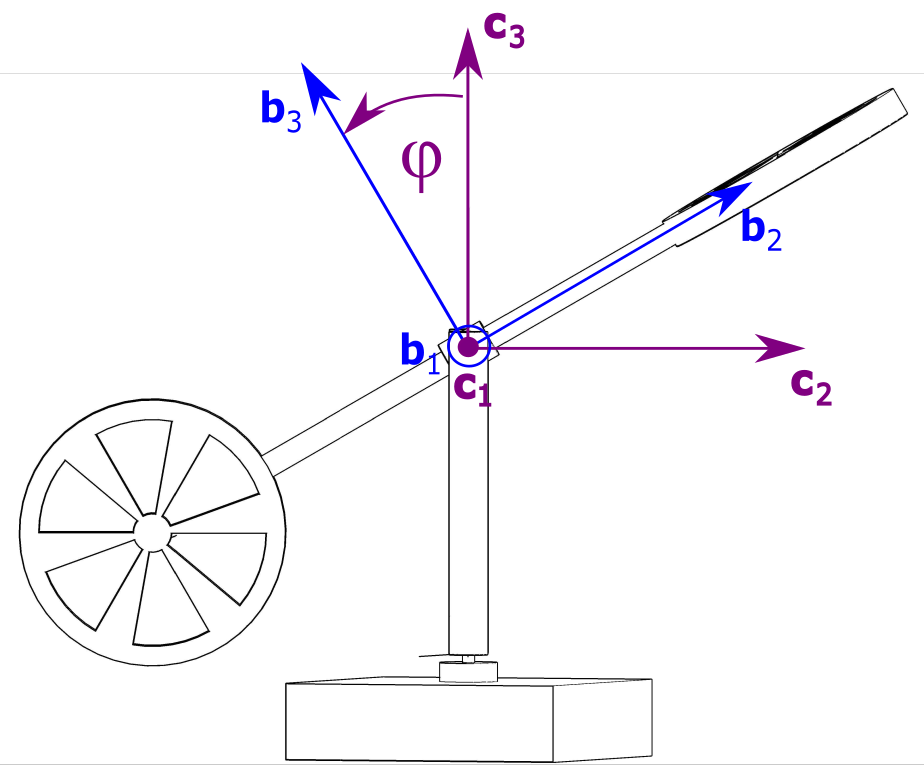

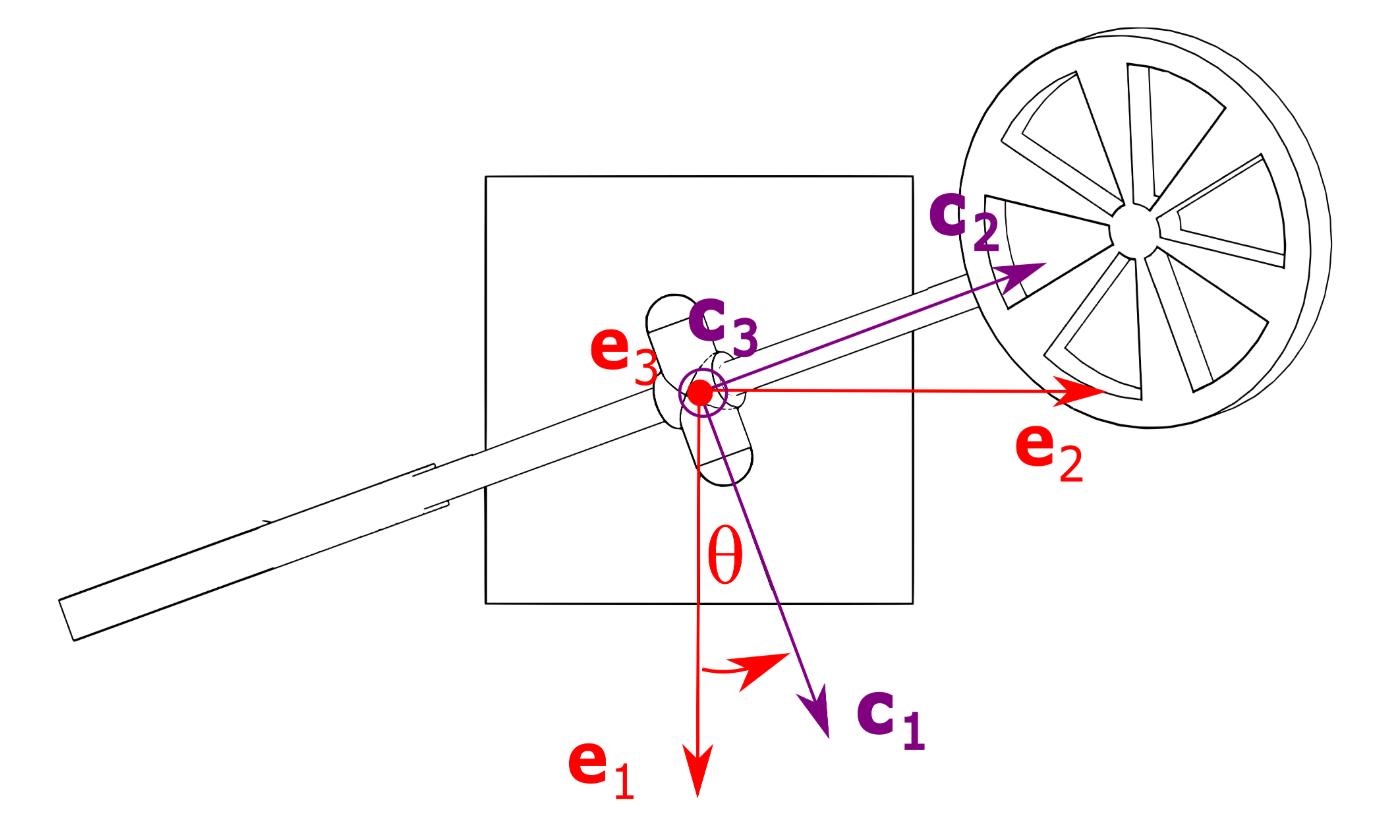

## 1. Reference Frames and Kinematics

The notations $\theta$ (yaw) and $\phi$ (pitch) as specified in the system diagrams.

### 1.1 Frame Definitions
We establish three right-handed orthonormal coordinate frames:
1.  **Inertial Frame ($\mathcal{E}$)**: Fixed to the laboratory floor. Basis vectors $\{\mathbf{e}_1, \mathbf{e}_2, \mathbf{e}_3\}$, where $\mathbf{e}_3$ is the vertical axis (gravity acts along $-\mathbf{e}_3$).
2.  **Intermediate Frame ($\mathcal{C}$)**: Fixed to the vertical tower but rotates with the yaw joint. Basis vectors $\{\mathbf{c}_1, \mathbf{c}_2, \mathbf{c}_3\}$. This frame is obtained by a rotation $\theta$ about $\mathbf{e}_3$.
3.  **Body-Fixed Frame ($\mathcal{B}$)**: Fixed to the rotor beam. Basis vectors $\{\mathbf{b}_1, \mathbf{b}_2, \mathbf{b}_3\}$. This frame is obtained by a rotation $\phi$ about the horizontal axis $\mathbf{c}_1$.


---

### 1.2 Rotation Matrix Derivation
The rotation from $\mathcal{E}$ to $\mathcal{C}$ is a Z-rotation by $\theta$:
$$
R_{yaw}(\theta) = R_3(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}
$$

The rotation from $\mathcal{C}$ to $\mathcal{B}$ is an X-rotation by $\phi$:
$$
R_{pitch}(\phi) = R_1(\phi) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\phi & -\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}
$$

The total rotation matrix $R$ (mapping $\mathcal{B}$ to $\mathcal{E}$) is computed as:
$$
R = R_3(\theta) R_1(\phi) = \begin{bmatrix} \cos\theta & -\sin\theta\cos\phi & \sin\theta\sin\phi \\ \sin\theta & \cos\theta\cos\phi & -\cos\theta\sin\phi \\ 0 & \sin\phi & \cos\phi \end{bmatrix}
$$

---

### 1.3 Kinematic Equations
The time derivative of the rotation matrix satisfies:
$$
\dot{R} = \widehat{\omega} R = R \widehat{\Omega}
$$
Where:
- $\omega$ is the **spatial angular velocity** (relative to $\mathcal{E}$).
- $\Omega$ is the **body angular velocity** (relative to $\mathcal{B}$).
- $\widehat{(\cdot)}$ is the skew-symmetric operator: $\widehat{x}y = x \times y$.

The relation between them is $\omega = R\Omega$.

---

## 2. Momentum and Velocity Mapping



### 2.1 Body and Spatial Angular Momentum
Let $\mathbb{I} = \text{diag}(I_1, I_2, I_3)$ be the inertia tensor in the body frame $\mathcal{B}$. The angular momentum in the body frame is:
$$
\Pi = \mathbb{I} \Omega
$$
The spatial angular momentum $\pi$ (observed from $\mathcal{E}$) is:
$$
\pi = R \Pi = R \mathbb{I} R^T \omega
$$

---
### 2.2 Spatial Inertia Tensor ($\mathbb{I}^R$)
We define the spatial inertia tensor as:
$$
\mathbb{I}^R = R \mathbb{I} R^T
$$
Substituting this into the momentum equation:
$$
\pi = \mathbb{I}^R \omega
$$

---
### 2.3 Explicit Velocity Derivation
To obtain the spatial angular velocity from the momentum state:
$$
\omega = (\mathbb{I}^R)^{-1} \pi
$$
This step is critical for the simulation as it map the integrated state $\pi$ back to the kinematic rate $\dot{R}$.

---


## 3. Newton-Euler Dynamics



The fundamental dynamic equation in the inertial frame is:
$$
\dot{\pi} = \tau^u + \tau^e
$$
Where $\tau^u$ is the control (rotor) torque and $\tau^e$ is the environment/constraint torque.

---

### 3.1 Derivation of Constraint Torque ($T_2$)
For most TRMS models, the system is constrained about the body axial axis $\mathbf{b}_2$ by the gimbal structure. The spatial constraint torque is:
$$
\tau^e = R \begin{bmatrix} 0 \\ T_2 \\ 0 \end{bmatrix}
$$

To find $T_2$, we look at the body-frame dynamics:
$$
\mathbb{I}\dot{\Omega} + \Omega \times (\mathbb{I}\Omega) = T^u_{\mathcal{B}} + T^3_{\mathcal{B}}
$$
Where $T^3_{\mathcal{B}} = [0, T_2, 0]^T$. Projecting onto the second body axis $\mathbf{e}_2$ (where $\mathbf{e}_2^T = [0, 1, 0]$):
$$
T_2 = \mathbf{e}_2^T \left( \mathbb{I}\dot{\Omega} + \Omega \times (\mathbb{I}\Omega) \right)
$$
Using $\dot{\Omega} = R^T \dot{\omega} - \Omega \times \Omega = R^T \dot{\omega}$, we verify that $T_2$ represents the reactionary torque of the gimbal.

---

### 3.2 Control Torque ($\tau^u$)
The rotors exert forces that create moments. Let $u_1$ be the thrust of the main rotor and $u_2$ the thrust of the tail rotor. The mapping follows:
$$
\tau^u = R \begin{bmatrix} 1 & 0 \\ 0 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \cos{\alpha} & -\cos{\beta} \\ \sin{\alpha} & -\sin{\beta} \end{bmatrix} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}
$$
This ensures that control inputs are correctly translated through the system's current attitude $R$.

## Matrices

In [ ]:
import sympy
from sympy import symbols, Matrix, sin, cos, simplify, diff
from sympy.physics.vector import dynamicsymbols

# Symbols
t = symbols('t')
theta, phi = dynamicsymbols('theta phi')
I1, I2, I3 = symbols('I1 I2 I3')

def R1(q):
    return Matrix([[1, 0, 0],[0, cos(q), -sin(q)],[0, sin(q), cos(q)]])

def R3(q):
    return Matrix([[cos(q), -sin(q), 0],[sin(q), cos(q), 0],[0, 0, 1]])

# 1. Full Rotation Matrix Calculation
R = simplify(R3(theta) * R1(phi))
print("Total Rotation Matrix R:")
display(R)

# 2. Spatial Inertia Calculation
II_body = Matrix([[I1, 0, 0], [0, I2, 0], [0, 0, I3]])
II_spatial = simplify(R * II_body * R.T)
print("Spatial Inertia Matrix (II^R):")
display(II_spatial)

# 3. Angular Velocity Mapping
# omega = (II^R)^-1 * pi
# (Implemented in simulation logic via solver)

print("\nDerivation steps for Task 1 fully implemented.")

# Task#2

## Simulation and Animation

Implementing the numerical simulation using the `rigid-body-sim` helper library.

In [10]:
# 1. Install simulation helpers
!pip install --quiet "git+https://github.com/mugalan/classical-mechanics-from-a-geometric-point-of-view.git#egg=rigid-body-sim"

import numpy as np
import sims
mr = sims.RigidBodySim()
print("Simulation environment initialized.")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Simulation environment initialized.


In [11]:
# 2. Define Force and Actuator Models

def externalForceModel(qq, parameters, X):
    # No external torques/forces for basic spin/swing tests
    fe = np.array([0, 0, 0])
    taue = np.array([0, 0, 0])
    return [taue, fe]

def actuator(qq, parameters, t, X, taue, fe):
    R = X[0][0]
    alpha = parameters.get('alpha', 0)
    beta = parameters.get('beta', 0)
    u1 = parameters.get('u1', 0.0)
    u2 = parameters.get('u2', 0.0)

    # Thrust mapping to spatial torque
    tauu = R @ [u1*np.cos(alpha)-u2*np.cos(beta), 0, u1*np.sin(alpha)-u2*np.sin(beta)]
    fu = np.array([0, 0, 0])

    return [tauu, fu]

mr.set_external_force_model(externalForceModel)
mr.set_actuator(actuator)
print("Actuator configured with rotor mapping.")

Actuator configured with rotor mapping.


In [12]:
# 3. Simulation 1: Vertical Axis Spin (Yaw)
print("Running Simulation: Vertical Axis Spin...")

# Beam Dimensions and Inertia (M=1, L=10)
L = 10.0
beamDim = {'l': L, 'w': 0.2, 'h': 0.2, 'xp': L/2, 'yp': 0.1, 'zp': 0.1}
I_beam = 1/12 * 1.0 * L**2
II = np.diag([0.01, I_beam, I_beam])
CM = np.array([beamDim['l']/2-beamDim['xp'], beamDim['w']/2-beamDim['yp'], beamDim['h']/2-beamDim['zp']])

parameters_yaw = {
    'g': 0.0, 'M': 1.0, 'II': II, 'CM': CM,
    'alpha': 0, 'beta': 0, 'u1': 0.2, 'u2': 0.0
}

ICR = np.eye(3)
ICOmega = np.array([0, 0, 0])
ICs = [[ICR, np.array([0,0,0])], ICR @ ICOmega, np.array([0,0,0]), np.array([0,0,0])]

data_yaw = mr.simulating_a_cube(0.1, 15.0, beamDim, parameters_yaw, ICs)
mr.animated_cube_flat_shading(data_yaw, 'TRMS: Vertical Axis Spin (Yaw)')

Running Simulation: Vertical Axis Spin...


In [13]:
# 4. Simulation 2: Horizontal Axis Swing (Pitch)
print("Running Simulation: Horizontal Axis Swing...")

parameters_pitch = parameters_yaw.copy()
parameters_pitch.update({
    'g': 9.81, 'u1': 0.1, 'u2': 0.1,
    'alpha': np.pi/2, 'beta': -np.pi/2
})

data_pitch = mr.simulating_a_cube(0.1, 15.0, beamDim, parameters_pitch, ICs)
mr.animated_cube_flat_shading(data_pitch, 'TRMS: Horizontal Axis Swing (Pitch)')

Running Simulation: Horizontal Axis Swing...
